In [ ]:
# ==========================================
# CELL 1 — Mount Google Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ==========================================
# CELL 2 — GPU Configuration
# ==========================================

import torch
import random
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Deterministic settings for reproducibility
torch.backends. cudnn.deterministic = True
# benchmark=False for training reproducibility
# (NB3 uses True for inference speed - intentional difference)
torch.backends. cudnn. benchmark = False

!nvidia-smi

Device: cuda
GPU Available: True
GPU Name: Tesla T4
CUDA Version: 12.8
Sat Jun  6 16:07:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        | 

In [ ]:
# ==========================================
# CELL 3 — Kaggle API Setup
# ==========================================

import os

KAGGLE_JSON_PATH = "/content/drive/MyDrive/kaggle/kaggle.json"

# Create Kaggle folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Validate file exists
if not os.path.exists(KAGGLE_JSON_PATH):
    raise FileNotFoundError(f"Kaggle API file not found: {KAGGLE_JSON_PATH}")

# Copy kaggle.json
!cp "{KAGGLE_JSON_PATH}" /root/.kaggle/

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

print("✅ Kaggle API ready.")

✅ Kaggle API ready.


In [ ]:
# ==========================================
# CELL 4 — Install Required Libraries
# FER-specific: EfficientNet, OpenCV, Kaggle
# ==========================================

!pip install -q \
    kaggle \
    opencv-python \
    seaborn

In [ ]:
# ==========================================
# CELL 5 — Import Libraries (FER)
# ==========================================

# Core
import os
import shutil
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import Counter
from PIL import Image

# Suppress warnings
warnings.filterwarnings("ignore")

# Image Processing
import cv2

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

# Torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print("✅ All FER libraries imported successfully.")

✅ All FER libraries imported successfully.


In [ ]:
# ============================================================
# ENVIRONMENT & PATH SETUP (Colab vs Local)
# ============================================================
import os, sys
if os.path.exists("/content/drive"):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass
    BASE_PATH = "/content/drive/MyDrive/Emotion_Story_Project1"
else:
    # Running locally or inside notebooks/ folder
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    BASE_PATH = PROJECT_ROOT

# Original path definitions below:
# ==========================================
# CELL 6 — Project Configuration (FER)
# ==========================================
# NOTE: All paths match the shared Drive folder structure
# used across FER, SER, Fusion, and Story Generation phases.

# ---- Emotion Classes (3-class subset for FER) ----
TARGET_CLASSES = ["happy", "neutral", "sad"]
NUM_CLASSES    = len(TARGET_CLASSES)

emotion_to_idx = {"happy": 0, "neutral": 1, "sad": 2}
idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}

print("Target Classes :", TARGET_CLASSES)
print("Number of Classes:", NUM_CLASSES)

# ---- Base Drive Path ----
BASE_PATH = "/content/drive/MyDrive/Emotion_Story_Project1"

os.makedirs(BASE_PATH, exist_ok=True)
assert os.path.exists(BASE_PATH), f"Base path not found: {BASE_PATH}"

# ---- Data Paths ----
DATA_PATH    = os.path.join(BASE_PATH, "data")
FER_PATH     = os.path.join(DATA_PATH, "fer2013")
RAVDESS_PATH = os.path.join(DATA_PATH, "ravdess")  # used by SER notebook

# ---- Model Paths ----
MODEL_PATH        = os.path.join(BASE_PATH, "models")
FACIAL_MODEL_PATH = os.path.join(MODEL_PATH, "facial")
AUDIO_MODEL_PATH  = os.path.join(MODEL_PATH, "audio")   # used by SER notebook
FUSION_MODEL_PATH = os.path.join(MODEL_PATH, "fusion")  # used by Fusion notebook

# ---- Output Paths ----
OUTPUT_PATH       = os.path.join(BASE_PATH, "outputs")
STORY_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "stories")
AUDIO_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "audio")
IMAGE_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "images")
VIDEO_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "video")
METRIC_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "metrics")

print("\n✅ Project paths configured.")
print(f"   Base  : {BASE_PATH}")
print(f"   FER   : {FACIAL_MODEL_PATH}")

Target Classes : ['happy', 'neutral', 'sad']
Number of Classes: 3

✅ Project paths configured.
   Base  : /content/drive/MyDrive/Emotion_Story_Project1
   FER   : /content/drive/MyDrive/Emotion_Story_Project1/models/facial


In [ ]:
# ==========================================
# CELL 7 — Create Project Directories
# ==========================================
# Creates the full shared Drive structure once.
# Safe to re-run (exist_ok=True).

folders = [
    FER_PATH,
    RAVDESS_PATH,
    FACIAL_MODEL_PATH,
    AUDIO_MODEL_PATH,
    FUSION_MODEL_PATH,
    STORY_OUTPUT_PATH,
    AUDIO_OUTPUT_PATH,
    IMAGE_OUTPUT_PATH,
    VIDEO_OUTPUT_PATH,
    METRIC_OUTPUT_PATH
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Verify
for folder in folders:
    assert os.path.exists(folder), f"Failed to create: {folder}"

print("✅ All project directories created/verified successfully.")

✅ All project directories created/verified successfully.


In [ ]:
# ==========================================
# CELL 8 — Download FER2013 Dataset
# ==========================================
# Downloads from Kaggle and saves to Drive.
# Skips automatically if already downloaded.

FER_PATH = os.path.join(DATA_PATH, "fer2013")

if not os.path.exists(FER_PATH):

    print("Downloading FER2013 dataset...")

    !rm -rf fer2013.zip
    !rm -rf fer2013

    # Download
    !kaggle datasets download -d msambare/fer2013

    # Extract
    !unzip -q fer2013.zip -d fer2013

    # Move to Drive (persistent storage)
    shutil.move("fer2013", FER_PATH)

    print("✅ FER2013 downloaded and saved to Drive.")

else:
    print("✅ FER2013 already exists. Skipping download.")

✅ FER2013 already exists. Skipping download.


In [ ]:
# ==========================================
# CELL 9 — Verify FER2013 Dataset
# ==========================================

train_dir = os.path.join(FER_PATH, "train")
test_dir  = os.path.join(FER_PATH, "test")

print("Train Classes:", sorted(os.listdir(train_dir)))
print("Test Classes :", sorted(os.listdir(test_dir)))

print("\nTraining Image Counts:")
for cls in sorted(os.listdir(train_dir)):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"  {cls}: {count}")

print("\nTest Image Counts:")
for cls in sorted(os.listdir(test_dir)):
    count = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"  {cls}: {count}")

Train Classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test Classes : ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Training Image Counts:
  angry: 3995
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171

Test Image Counts:
  angry: 958
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831


In [ ]:
# ==========================================
# CELL 10 — Remove 'disgust' Class
# ==========================================
# FER2013 has 7 classes. This project uses 3 (happy, neutral, sad).
# 'disgust' is removed here; remaining non-target classes are
# filtered at dataset load time (Cell 14).

train_path = os.path.join(FER_PATH, "train")
test_path  = os.path.join(FER_PATH, "test")

disgust_train = os.path.join(train_path, "disgust")
disgust_test  = os.path.join(test_path,  "disgust")

if os.path.exists(disgust_train):
    shutil.rmtree(disgust_train)
    print("✅ Removed 'disgust' from train set.")

if os.path.exists(disgust_test):
    shutil.rmtree(disgust_test)
    print("✅ Removed 'disgust' from test set.")

print("\nUpdated Train Classes:", sorted(os.listdir(train_path)))
print("Updated Test Classes :", sorted(os.listdir(test_path)))


Updated Train Classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Updated Test Classes : ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# **PHASE 1 — Facial Emotion Recognition (FER)**

In [ ]:
# ==========================================
# CELL 11 — Create Clean FER2013 ZIP
# RUN THIS ONLY ONCE after first download.
# Re-running is safe but wastes time.
# ==========================================

import os

print("📦 Creating clean FER2013 ZIP...")

# Ensure we are in /content for local operations
%cd /content

# Remove stale zip
!rm -f /content/fer2013.zip

# Copy dataset locally first, then zip - avoids Drive I/O interrupt issues
# This ensures the zip operation happens on local storage, not across the Drive mount directly.
!cp -r "/content/drive/MyDrive/Emotion_Story_Project1/data/fer2013" /content/

# Create ZIP from the local copy
!zip -rq /content/fer2013.zip fer2013

# Verify zip was actually created before copying
if os.path.exists("/content/fer2013.zip"):
    print("✅ ZIP created!")

    # Persist to Drive
    !cp /content/fer2013.zip \
        /content/drive/MyDrive/Emotion_Story_Project1/data/

    print("✅ ZIP saved to Drive.")

else:
    raise RuntimeError("❌ ZIP creation failed - do not proceed to Cell 13.")

# ---- IMPORTANT: Reset working directory back to /content ----
# (just in case it was changed by a previous command, though %cd /content above handles it)
%cd /content

print("✅ Working directory reset to /content")
print("📁 Current directory:", os.getcwd())

📦 Creating clean FER2013 ZIP...
/content
✅ ZIP created!
✅ ZIP saved to Drive.
/content
✅ Working directory reset to /content
📁 Current directory: /content


In [ ]:
# ==========================================
# FAST LOCAL DATASET SETUP
# Cell 12
# ==========================================

print("🧹 Cleaning old local dataset...")

!rm -rf /content/fer2013
!rm -f /content/fer2013.zip

print("📦 Copying ZIP from Drive...")

!cp \
"/content/drive/MyDrive/Emotion_Story_Project1/data/fer2013.zip" \
/content/

print("📂 Extracting locally...")

!unzip -q /content/fer2013.zip -d /content/

print("✅ FER dataset ready locally!")

# Verify
print("\n📁 Local Dataset Structure:")

!ls /content/fer2013

🧹 Cleaning old local dataset...
📦 Copying ZIP from Drive...
📂 Extracting locally...
✅ FER dataset ready locally!

📁 Local Dataset Structure:
test  train


In [ ]:
# ==========================================
# CELL 13 — FER Dataset + Transforms
# ==========================================

IMG_SIZE   = 224
BATCH_SIZE = 32

# ---- Transforms ----

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# ---- Custom Dataset ----

class FERDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir   = root_dir
        self.transform  = transform
        self.image_paths = []
        self.labels      = []
        self.class_names = TARGET_CLASSES
        self.class_to_idx = emotion_to_idx

        for class_name in self.class_names:
            class_path = os.path.join(root_dir, class_name)

            if not os.path.exists(class_path):
                print(f"❌ Missing: {class_path}")
                continue

            for img_name in sorted(os.listdir(class_path)):
                if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(self.class_to_idx[class_name])

        print(f"✅ Loaded {len(self.image_paths)} images from {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("L")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# ---- Dataset Paths (local SSD) ----

train_dir = "/content/fer2013/train"
test_dir  = "/content/fer2013/test"

print("\n📁 Checking dataset structure...")
print("Train folders:", os.listdir(train_dir))
print("Test folders :", os.listdir(test_dir))

# ---- Create Datasets & DataLoaders ----

train_dataset = FERDataset(train_dir, transform=train_transforms)
val_dataset   = FERDataset(test_dir,  transform=val_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# ---- Summary ----

print("\n==========================================")
print("FER Dataset Summary")
print("==========================================")
print("Train Samples     :", len(train_dataset))
print("Validation Samples:", len(val_dataset))

label_counts = Counter(train_dataset.labels)
print("\nClass Distribution (Train):")
for idx, count in sorted(label_counts.items()):
    print(f"  {idx_to_emotion[idx]:<10}: {count}")

sample_images, sample_labels = next(iter(train_loader))
print("\nBatch Shape :", sample_images.shape)
print("Label Shape :", sample_labels.shape)
print("\n✅ FER Dataset + Transforms Ready.")


📁 Checking dataset structure...
Train folders: ['fear', 'surprise', 'neutral', 'sad', 'angry', 'happy']
Test folders : ['fear', 'surprise', 'neutral', 'sad', 'angry', 'happy']
✅ Loaded 17010 images from /content/fer2013/train
✅ Loaded 4254 images from /content/fer2013/test

FER Dataset Summary
Train Samples     : 17010
Validation Samples: 4254

Class Distribution (Train):
  happy     : 7215
  neutral   : 4965
  sad       : 4830

Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape : torch.Size([32])

✅ FER Dataset + Transforms Ready.


In [ ]:
# ==========================================
# CELL 14 — Load EfficientNet-B2
# ==========================================
# Uses torchvision's built-in EfficientNet-B2.
# Backbone frozen; only the classifier head is trained in Stage 1.

model = models.efficientnet_b2(
    weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1
)

print("✅ Pretrained EfficientNet-B2 loaded.")

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head (3-class output)
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

# Xavier init
nn.init.xavier_uniform_(model.classifier[1].weight)
if model.classifier[1].bias is not None:
    nn.init.constant_(model.classifier[1].bias, 0)

model = model.to(device)

print("✅ Model moved to:", device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print("\n==========================================")
print("EfficientNet-B2 Summary")
print("==========================================")
print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")
print(f"Trainable %          : {(trainable/total)*100:.2f}%")
print("\nClassifier Head:")
print(model.classifier)
print("\n✅ EfficientNet-B2 Ready for Training.")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 163MB/s]


✅ Pretrained EfficientNet-B2 loaded.
✅ Model moved to: cuda

EfficientNet-B2 Summary
Trainable Parameters : 4,227
Total Parameters     : 7,705,221
Trainable %          : 0.05%

Classifier Head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1408, out_features=3, bias=True)
)

✅ EfficientNet-B2 Ready for Training.


In [ ]:
# ==========================================
# CELL 15 — Stage 1 Training
# Partial Fine-Tuning | 3-Class | 12 Epochs
# ==========================================
# Unfreezes the last 3 EfficientNet blocks + classifier.
# Uses weighted CrossEntropy to handle class imbalance.

from tqdm import tqdm

# ---- Unfreeze Last 3 Blocks + Classifier ----

for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

print("✅ Trainable Parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---- Class Weights — Computed from Actual Data Distribution ----
# Formula: weight[i] = total_samples / (num_classes * count[i])
# This gives higher weight to minority classes automatically.

label_counts  = Counter(train_dataset.labels)
total_samples = len(train_dataset.labels)

class_weights = torch.tensor(
    [
        total_samples / (NUM_CLASSES * label_counts[i])
        for i in range(NUM_CLASSES)
    ],
    dtype=torch.float
).to(device)

print("📊 Computed Class Weights:")
for i, name in enumerate(TARGET_CLASSES):
    print(f"   {name:<10}: {class_weights[i].item():.4f}  "
          f"(count={label_counts[i]})")

criterion = nn.CrossEntropyLoss(weight=class_weights)


# ---- Optimizer & Scheduler ----

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

# ---- Training Config ----

EPOCHS      = 12
best_val_acc = 0.0
best_model_wts = None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("\n✅ Starting Stage-1 Training...\n")

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 50)

    # --- TRAIN ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # --- VALIDATION ---
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("LR:", optimizer.param_groups[0]['lr'])

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        save_path = os.path.join(FACIAL_MODEL_PATH, "best_face_model_stage1_3class.pth")
        torch.save(best_model_wts, save_path)
        print(f"✅ Best Stage-1 model saved: {save_path}")

    torch.cuda.empty_cache()

# ---- Restore Best Weights ----

print("\n===================================")
print("✅ Stage-1 Training Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("===================================")

if best_model_wts:
    model.load_state_dict(best_model_wts)
    model = model.to(device)
    print("✅ Best weights restored.")

# Save history
history_path = os.path.join(FACIAL_MODEL_PATH, "stage1_training_history_3class.json")
with open(history_path, "w") as f:
    json.dump(history, f)
print("📊 Stage-1 training history saved.")

✅ Trainable Parameters: 6287357
📊 Computed Class Weights:
   happy     : 0.7859  (count=7215)
   neutral   : 1.1420  (count=4965)
   sad       : 1.1739  (count=4830)

✅ Starting Stage-1 Training...


Epoch [1/12]
--------------------------------------------------


Train Loss: 0.7988 | Train Acc: 0.6483
Val   Loss: 0.6334 | Val   Acc: 0.7184
LR: 0.0001
✅ Best Stage-1 model saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/best_face_model_stage1_3class.pth

Epoch [2/12]
--------------------------------------------------


Train Loss: 0.6194 | Train Acc: 0.7419
Val   Loss: 0.5566 | Val   Acc: 0.7551
LR: 0.0001
✅ Best Stage-1 model saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/best_face_model_stage1_3class.pth

Epoch [3/12]
--------------------------------------------------


Train Loss: 0.5526 | Train Acc: 0.7783
Val   Loss: 0.5478 | Val   Acc: 0.7670
LR: 0.0001
✅ Best Stage-1 model saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/best_face_model_stage1_3class.pth

Epoch [4/12]
--------------------------------------------------


Train Loss: 0.5091 | Train Acc: 0.7986
Val   Loss: 0.5263 | Val   Acc: 0.7750
LR: 0.0001
✅ Best Stage-1 model saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/best_face_model_stage1_3class.pth

Epoch [5/12]
--------------------------------------------------


...

Train Loss: 0.3653 | Train Acc: 0.8587
Val   Loss: 0.5672 | Val   Acc: 0.7910
LR: 0.0001

Epoch [9/12]
--------------------------------------------------


Train Loss: 0.3284 | Train Acc: 0.8761
Val   Loss: 0.5851 | Val   Acc: 0.7957
LR: 0.0001
✅ Best Stage-1 model saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/best_face_model_stage1_3class.pth

Epoch [10/12]
--------------------------------------------------


Train Loss: 0.3085 | Train Acc: 0.8831
Val   Loss: 0.6051 | Val   Acc: 0.7913
LR: 0.0001

Epoch [11/12]
--------------------------------------------------


Train Loss: 0.2859 | Train Acc: 0.8932
Val   Loss: 0.6319 | Val   Acc: 0.7917
LR: 0.0001

Epoch [12/12]
--------------------------------------------------


Train Loss: 0.2639 | Train Acc: 0.9032
Val   Loss: 0.6558 | Val   Acc: 0.7955
LR: 0.0001

✅ Stage-1 Training Complete!
Best Validation Accuracy: 0.7957
✅ Best weights restored.
📊 Stage-1 training history saved.


🔍 Running FER Evaluation...

FER Overall Metrics
Accuracy          : 0.7957
Macro Precision   : 0.7836
Macro Recall      : 0.7833
Macro F1          : 0.7821
Weighted F1       : 0.7973


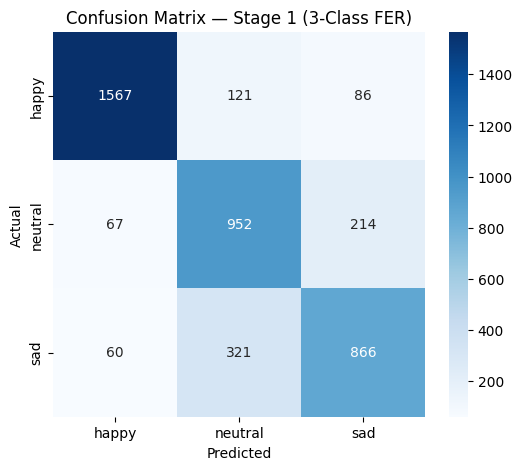

✅ CM saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/stage1_confusion_matrix_3class.png


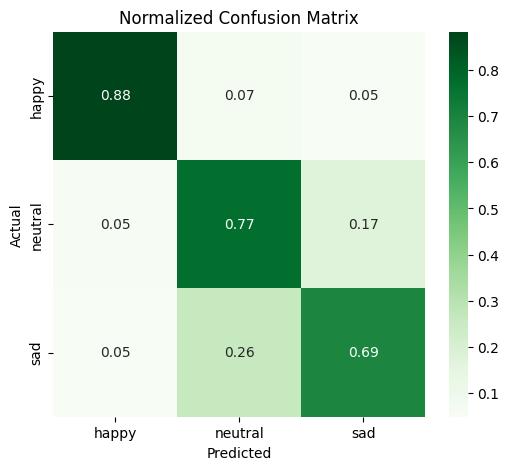


Per-Class Accuracy:
  happy     : 0.8833
  neutral   : 0.7721
  sad       : 0.6945
✅ Metrics JSON saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/stage1_metrics_3class.json

Classification Report
              precision    recall  f1-score   support

       happy       0.93      0.88      0.90      1774
     neutral       0.68      0.77      0.72      1233
         sad       0.74      0.69      0.72      1247

    accuracy                           0.80      4254
   macro avg       0.78      0.78      0.78      4254
weighted avg       0.80      0.80      0.80      4254

✅ Classification report saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/stage1_classification_report.txt

🚀 Phase 1 Evaluation Complete.


In [ ]:
# ==========================================
# CELL 16 — Evaluation Metrics (Stage 1)
# ==========================================

torch.cuda.empty_cache()
model = model.to(device)
model.eval()

all_preds, all_labels_eval = [], []

print("🔍 Running FER Evaluation...\n")

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_eval.extend(labels.cpu().numpy())

all_preds       = np.array(all_preds)
all_labels_eval = np.array(all_labels_eval)

# ---- Metrics ----

acc              = accuracy_score(all_labels_eval, all_preds)
precision_macro  = precision_score(all_labels_eval, all_preds, average='macro',    zero_division=0)
recall_macro     = recall_score(   all_labels_eval, all_preds, average='macro',    zero_division=0)
f1_macro         = f1_score(       all_labels_eval, all_preds, average='macro',    zero_division=0)
f1_weighted      = f1_score(       all_labels_eval, all_preds, average='weighted', zero_division=0)

print("==========================================")
print("FER Overall Metrics")
print("==========================================")
print(f"Accuracy          : {acc:.4f}")
print(f"Macro Precision   : {precision_macro:.4f}")
print(f"Macro Recall      : {recall_macro:.4f}")
print(f"Macro F1          : {f1_macro:.4f}")
print(f"Weighted F1       : {f1_weighted:.4f}")

class_names = ["happy", "neutral", "sad"]
cm           = confusion_matrix(all_labels_eval, all_preds)
cm_norm      = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# ---- Raw Confusion Matrix ----

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Stage 1 (3-Class FER)")
cm_path = os.path.join(FACIAL_MODEL_PATH, "stage1_confusion_matrix_3class.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ CM saved: {cm_path}")

# ---- Normalized CM ----

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=class_names, yticklabels=class_names, cmap="Greens")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
norm_path = os.path.join(FACIAL_MODEL_PATH, "stage1_confusion_matrix_normalized.png")
plt.savefig(norm_path, dpi=300, bbox_inches='tight')
plt.show()

# ---- Per-Class Accuracy ----

print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    print(f"  {name:<10}: {cm[i, i] / cm[i].sum():.4f}")

# ---- Save Metrics JSON ----

metrics = {
    "accuracy":           float(acc),
    "precision_macro":    float(precision_macro),
    "recall_macro":       float(recall_macro),
    "f1_macro":           float(f1_macro),
    "f1_weighted":        float(f1_weighted)
}
metrics_path = os.path.join(FACIAL_MODEL_PATH, "stage1_metrics_3class.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)
print(f"✅ Metrics JSON saved: {metrics_path}")

# ---- Classification Report ----

report = classification_report(all_labels_eval, all_preds,
                                target_names=class_names, zero_division=0)
print("\n==========================================")
print("Classification Report")
print("==========================================")
print(report)

report_path = os.path.join(FACIAL_MODEL_PATH, "stage1_classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)
print(f"✅ Classification report saved: {report_path}")
print("\n🚀 Phase 1 Evaluation Complete.")

In [ ]:
# ==========================================
# CELL 17 — Stage 2 Setup
# Conservative Fine-Tuning (3-Class)
# ==========================================
# Loads Stage-1 best weights, unfreezes last 4 blocks,
# and uses differential learning rates for backbone vs classifier.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Re-initialize EfficientNet-B2 ----

model = models.efficientnet_b2(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

# ---- Load Stage-1 Weights ----

model_path = os.path.join(FACIAL_MODEL_PATH, "best_face_model_stage1_3class.pth")
state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)

print("✅ Stage-1 model loaded successfully.")

# ---- Freeze → Unfreeze Strategy ----

for param in model.parameters():
    param.requires_grad = False

for param in model.features[-4:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

print("✅ Last 4 EfficientNet blocks + classifier unfrozen.")

# ---- Differential Learning Rates ----

backbone_params   = []
classifier_params = []

for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if "classifier" in name:
        classifier_params.append(param)
    else:
        backbone_params.append(param)

optimizer = optim.AdamW(
    [
        {"params": backbone_params,   "lr": 5e-6},
        {"params": classifier_params, "lr": 2e-5}
    ],
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Trainable Parameters: {trainable:,}")
print("✅ Stage-2 setup complete.")

Using device: cuda
✅ Stage-1 model loaded successfully.
✅ Last 4 EfficientNet blocks + classifier unfrozen.
✅ Trainable Parameters: 7,150,125
✅ Stage-2 setup complete.


In [ ]:
# ==========================================
# CELL 18 — Stage 2 Training Loop
# Conservative Fine-Tuning | 5 Epochs
# ==========================================

from tqdm import tqdm

# ---- Class Weights — Same computation as Stage 1 ----
# Keeps loss consistent across both training stages.

label_counts_s2  = Counter(train_dataset.labels)
total_samples_s2 = len(train_dataset.labels)

class_weights_s2 = torch.tensor(
    [
        total_samples_s2 / (NUM_CLASSES * label_counts_s2[i])
        for i in range(NUM_CLASSES)
    ],
    dtype=torch.float
).to(device)

print("📊 Stage-2 Class Weights:")
for i, name in enumerate(TARGET_CLASSES):
    print(f"   {name:<10}: {class_weights_s2[i].item():.4f}  "
          f"(count={label_counts_s2[i]})")

criterion = nn.CrossEntropyLoss(weight=class_weights_s2)

EPOCHS         = 5
best_val_acc   = 0.0
best_model_wts = None

history_stage2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("\n🚀 Starting Stage-2 Fine-Tuning...\n")

for epoch in range(EPOCHS):

    print(f"\nStage-2 Epoch [{epoch+1}/{EPOCHS}]")
    print("-" * 50)

    # --- TRAIN ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # --- VALIDATION ---
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    scheduler.step()

    history_stage2["train_loss"].append(train_loss)
    history_stage2["val_loss"].append(val_loss)
    history_stage2["train_acc"].append(train_acc)
    history_stage2["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("LR:", optimizer.param_groups[0]['lr'])

    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        save_path = os.path.join(FACIAL_MODEL_PATH, "best_face_model_stage2_3class.pth")
        torch.save(best_model_wts, save_path)
        print(f"✅ Stage-2 best model saved: {save_path}")

    torch.cuda.empty_cache()

# ---- Final ----

print("\n===================================")
print("✅ Stage-2 Training Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("===================================")

if best_model_wts:
    model.load_state_dict(best_model_wts)
    model = model.to(device)
    print("✅ Best Stage-2 weights restored.")

history_path = os.path.join(FACIAL_MODEL_PATH, "stage2_training_history_3class.json")
with open(history_path, "w") as f:
    json.dump(history_stage2, f, indent=4)
print("📊 Stage-2 training history saved.")

📊 Stage-2 Class Weights:
   happy     : 0.7859  (count=7215)
   neutral   : 1.1420  (count=4965)
   sad       : 1.1739  (count=4830)

🚀 Starting Stage-2 Fine-Tuning...


Stage-2 Epoch [1/5]
--------------------------------------------------


Train Loss: 0.2857 | Train Acc: 0.8909
Val   Loss: 0.5682 | Val   Acc: 0.7985
LR: 4.809698831278217e-06
✅ Stage-2 best model saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/best_face_model_stage2_3class.pth

Stage-2 Epoch [2/5]
--------------------------------------------------


Train Loss: 0.2668 | Train Acc: 0.9002
Val   Loss: 0.5708 | Val   Acc: 0.7983
LR: 4.2677669529663685e-06

Stage-2 Epoch [3/5]
--------------------------------------------------


Train Loss: 0.2567 | Train Acc: 0.9048
Val   Loss: 0.5733 | Val   Acc: 0.7957
LR: 3.4567085809127247e-06

Stage-2 Epoch [4/5]
--------------------------------------------------


Train Loss: 0.2563 | Train Acc: 0.9069
Val   Loss: 0.5787 | Val   Acc: 0.7974
LR: 2.4999999999999998e-06

Stage-2 Epoch [5/5]
--------------------------------------------------


Train Loss: 0.2523 | Train Acc: 0.9066
Val   Loss: 0.5826 | Val   Acc: 0.7962
LR: 1.5432914190872755e-06

✅ Stage-2 Training Complete!
Best Validation Accuracy: 0.7985
✅ Best Stage-2 weights restored.
📊 Stage-2 training history saved.


🔍 Running Stage-2 FER Evaluation...

Stage-2 FER Overall Metrics
Accuracy          : 0.7985
Macro Precision   : 0.7848
Macro Recall      : 0.7859
Macro F1          : 0.7851
Weighted F1       : 0.8000


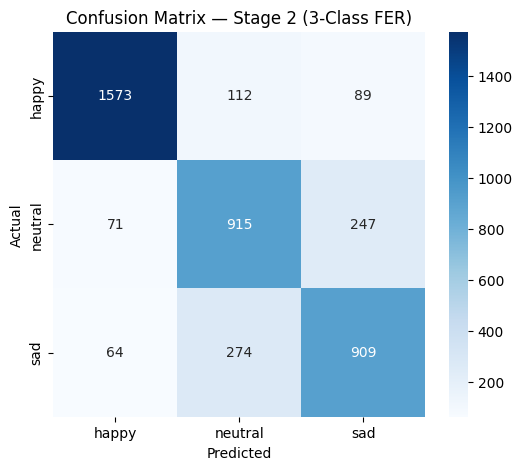

✅ CM saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/stage2_confusion_matrix_3class.png


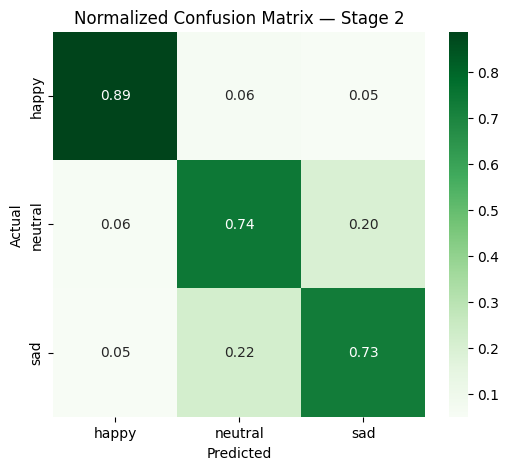


Per-Class Accuracy:
  happy     : 0.8867
  neutral   : 0.7421
  sad       : 0.7289
✅ Stage-2 metrics saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/stage2_metrics_3class.json

Stage-2 Classification Report
              precision    recall  f1-score   support

       happy       0.92      0.89      0.90      1774
     neutral       0.70      0.74      0.72      1233
         sad       0.73      0.73      0.73      1247

    accuracy                           0.80      4254
   macro avg       0.78      0.79      0.79      4254
weighted avg       0.80      0.80      0.80      4254

✅ Classification report saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/stage2_classification_report.txt

Stage 1 vs Stage 2 Comparison
Metric                  Stage 1    Stage 2      Delta
----------------------------------------------------
  accuracy               0.7957     0.7985 ▲  0.0028
  f1_macro               0.7821     0.7851 ▲  0.0030
  f1_weighted           

In [ ]:
# ==========================================
# CELL 19 — Evaluation Metrics (Stage 2)
# ==========================================
# Evaluates the best Stage-2 model on the validation set.
# Saves confusion matrix, classification report, and metrics JSON.
# Mirrors Stage-1 evaluation for direct comparison.

torch.cuda.empty_cache()
model = model.to(device)
model.eval()

all_preds_s2, all_labels_s2 = [], []

print("🔍 Running Stage-2 FER Evaluation...\n")

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds_s2.extend(preds.cpu().numpy())
        all_labels_s2.extend(labels.cpu().numpy())

all_preds_s2  = np.array(all_preds_s2)
all_labels_s2 = np.array(all_labels_s2)

# ---- Metrics ----

acc_s2             = accuracy_score(all_labels_s2, all_preds_s2)
precision_macro_s2 = precision_score(all_labels_s2, all_preds_s2, average='macro',    zero_division=0)
recall_macro_s2    = recall_score(   all_labels_s2, all_preds_s2, average='macro',    zero_division=0)
f1_macro_s2        = f1_score(       all_labels_s2, all_preds_s2, average='macro',    zero_division=0)
f1_weighted_s2     = f1_score(       all_labels_s2, all_preds_s2, average='weighted', zero_division=0)

print("==========================================")
print("Stage-2 FER Overall Metrics")
print("==========================================")
print(f"Accuracy          : {acc_s2:.4f}")
print(f"Macro Precision   : {precision_macro_s2:.4f}")
print(f"Macro Recall      : {recall_macro_s2:.4f}")
print(f"Macro F1          : {f1_macro_s2:.4f}")
print(f"Weighted F1       : {f1_weighted_s2:.4f}")

class_names = ["happy", "neutral", "sad"]
cm_s2       = confusion_matrix(all_labels_s2, all_preds_s2)
cm_norm_s2  = cm_s2.astype('float') / cm_s2.sum(axis=1)[:, np.newaxis]

# ---- Raw Confusion Matrix ----

plt.figure(figsize=(6, 5))
sns.heatmap(cm_s2, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Stage 2 (3-Class FER)")
cm_path_s2 = os.path.join(FACIAL_MODEL_PATH, "stage2_confusion_matrix_3class.png")
plt.savefig(cm_path_s2, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ CM saved: {cm_path_s2}")

# ---- Normalized Confusion Matrix ----

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm_s2, annot=True, fmt=".2f",
            xticklabels=class_names, yticklabels=class_names, cmap="Greens")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix — Stage 2")
norm_path_s2 = os.path.join(FACIAL_MODEL_PATH, "stage2_confusion_matrix_normalized.png")
plt.savefig(norm_path_s2, dpi=300, bbox_inches='tight')
plt.show()

# ---- Per-Class Accuracy ----

print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    print(f"  {name:<10}: {cm_s2[i, i] / cm_s2[i].sum():.4f}")

# ---- Save Metrics JSON ----

metrics_s2 = {
    "accuracy":        float(acc_s2),
    "precision_macro": float(precision_macro_s2),
    "recall_macro":    float(recall_macro_s2),
    "f1_macro":        float(f1_macro_s2),
    "f1_weighted":     float(f1_weighted_s2)
}
metrics_path_s2 = os.path.join(FACIAL_MODEL_PATH, "stage2_metrics_3class.json")
with open(metrics_path_s2, "w") as f:
    json.dump(metrics_s2, f, indent=4)
print(f"✅ Stage-2 metrics saved: {metrics_path_s2}")

# ---- Classification Report ----

report_s2 = classification_report(all_labels_s2, all_preds_s2,
                                   target_names=class_names, zero_division=0)
print("\n==========================================")
print("Stage-2 Classification Report")
print("==========================================")
print(report_s2)

report_path_s2 = os.path.join(FACIAL_MODEL_PATH, "stage2_classification_report.txt")
with open(report_path_s2, "w") as f:
    f.write(report_s2)
print(f"✅ Classification report saved: {report_path_s2}")

# ---- Stage 1 vs Stage 2 Comparison ----

stage1_metrics_path = os.path.join(FACIAL_MODEL_PATH, "stage1_metrics_3class.json")

if os.path.exists(stage1_metrics_path):
    with open(stage1_metrics_path, "r") as f:
        metrics_s1 = json.load(f)

    print("\n==========================================")
    print("Stage 1 vs Stage 2 Comparison")
    print("==========================================")
    print(f"{'Metric':<20} {'Stage 1':>10} {'Stage 2':>10} {'Delta':>10}")
    print("-" * 52)
    for key in ["accuracy", "f1_macro", "f1_weighted"]:
        s1_val = metrics_s1[key]
        s2_val = metrics_s2[key]
        delta  = s2_val - s1_val
        arrow  = "▲" if delta > 0 else "▼" if delta < 0 else "="
        print(f"  {key:<18} {s1_val:>10.4f} {s2_val:>10.4f} {arrow}{abs(delta):>8.4f}")
else:
    print("\n⚠️  Stage-1 metrics JSON not found — skipping comparison.")

print("\n🚀 Stage-2 Evaluation Complete.")

✅ Stage-2 model loaded for manual testing.

--- Running Batch Inference ---
  happy_001.jpg                  GT: happy      Pred: happy
  happy_002.jpg                  GT: happy      Pred: happy
  happy_003.jpg                  GT: happy      Pred: happy
  happy_004.jpg                  GT: happy      Pred: happy
  happy_005.jpg                  GT: happy      Pred: happy
  happy_006.jpg                  GT: happy      Pred: happy
  happy_007.jpg                  GT: happy      Pred: happy
  happy_008.jpg                  GT: happy      Pred: happy
  happy_009.jpg                  GT: happy      Pred: happy
  happy_010.jpg                  GT: happy      Pred: happy
  happy_011.jpg                  GT: happy      Pred: sad
  happy_012.jpg                  GT: happy      Pred: happy
  happy_013.jpg                  GT: happy      Pred: happy
  happy_014.jpg                  GT: happy      Pred: happy
  happy_015.jpg                  GT: happy      Pred: happy
  happy_016.jpg           

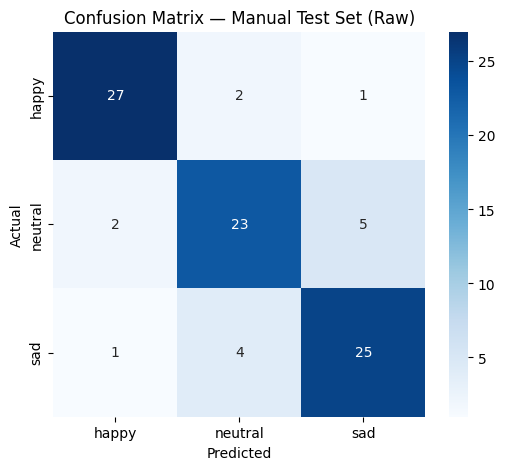

✅ Raw Confusion Matrix saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/test_set_reports/test_set_confusion_matrix_raw.png


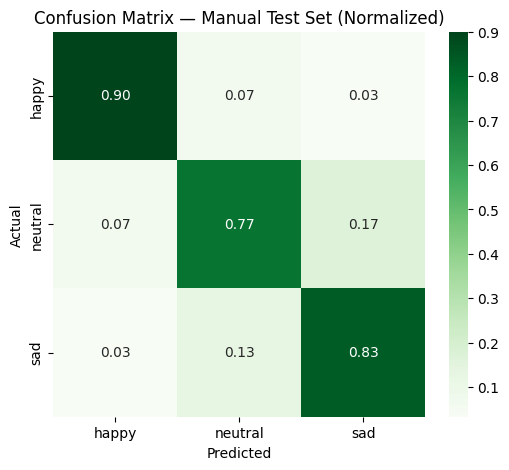

✅ Normalized Confusion Matrix saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/test_set_reports/test_set_confusion_matrix_normalized.png

Per-Class Accuracy:
  happy     : 0.9000
  neutral   : 0.7667
  sad       : 0.8333

Classification Report
              precision    recall  f1-score   support

       happy       0.90      0.90      0.90        30
     neutral       0.79      0.77      0.78        30
         sad       0.81      0.83      0.82        30

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.83      0.83      0.83        90

✅ Classification Report saved: /content/drive/MyDrive/Emotion_Story_Project1/models/facial/test_set_reports/test_set_classification_report.txt


In [ ]:
# ==========================================
# CELL 20 — Manual Testing (FER)
# Batch-test the trained Stage-2 model on a
# folder of real images with full evaluation.
# ==========================================

DEBUG_MODE = False # Set to True for verbose per-image output

# Define TEST_IMAGES_PATH here for local scope, using DATA_PATH from Cell 6
TEST_IMAGES_PATH = os.path.join(DATA_PATH, "test_images")

# ============================================================
# STEP 1 — Load the Final Stage-2 Model Fresh from Drive
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reconstruct exact architecture used in training
test_model = models.efficientnet_b2(weights=None)

in_features = test_model.classifier[1].in_features
test_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

# Load best Stage-2 weights
_model_path = os.path.join(FACIAL_MODEL_PATH, "best_face_model_stage2_3class.pth")
assert os.path.exists(_model_path), f"❌ Model not found: {_model_path}"

state_dict = torch.load(_model_path, map_location=device, weights_only=True)
test_model.load_state_dict(state_dict)
test_model = test_model.to(device)
test_model.eval()

print("✅ Stage-2 model loaded for manual testing.")

# ============================================================
# STEP 2 — Preprocessing Pipeline
# MUST match training transforms exactly (Cell 14)
# ============================================================

_IMG_SIZE = 224

_test_transform = transforms.Compose([
    transforms.Resize((_IMG_SIZE, _IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

_EMOTION_LABELS = TARGET_CLASSES # Use TARGET_CLASSES for consistency

# ============================================================
# STEP 3 — Face Detection + Inference Function
# ============================================================

_face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def predict_single_image(image_path, show=True):
    """
    Run FER on a single image file.
    Returns: (predicted_emotion, probabilities_dict)
    """

    # Load image
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"❌ Cannot read image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Face detection
    faces = _face_detector.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if DEBUG_MODE:
        if len(faces) == 0:
            print("⚠️  No face detected — using full image.")
        else:
            print("✅ Face detected.")

    if len(faces) == 0:
        face_rgb = img_rgb
        box = None
    else:
        # Use largest detected face
        x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        face_rgb    = img_rgb[y:y+h, x:x+w]
        box = (x, y, w, h)

    # Preprocess
    pil_face = Image.fromarray(face_rgb)
    tensor   = _test_transform(pil_face).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        logits = test_model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx     = int(np.argmax(probs))
    pred_emotion = _EMOTION_LABELS[pred_idx]
    confidence   = float(probs[pred_idx])

    probs_dict = {label: float(probs[i]) for i, label in enumerate(_EMOTION_LABELS)}

    # Display plots only if show is True AND DEBUG_MODE is True
    if show and DEBUG_MODE:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Left: original image with face box
        display_img = img_rgb.copy()
        if box:
            x, y, w, h = box
            cv2.rectangle(display_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        axes[0].imshow(display_img)
        axes[0].set_title("Input Image (Face Box)")
        axes[0].axis("off")

        # Right: probability bar chart
        colors = ["#4CAF50" if l == pred_emotion else "#90CAF9"
                  for l in _EMOTION_LABELS]
        axes[1].barh(_EMOTION_LABELS, probs, color=colors)
        axes[1].set_xlim(0, 1)
        axes[1].set_xlabel("Probability")
        axes[1].set_title(f"Prediction: {pred_emotion.upper()}  ({confidence:.1%})")
        for i, p in enumerate(probs):
            axes[1].text(p + 0.01, i, f"{p:.3f}", va="center")

        plt.suptitle(os.path.basename(image_path), fontsize=11)
        plt.tight_layout()
        plt.show()

    # Print details only if DEBUG_MODE is True
    if DEBUG_MODE:
        print(f"\n🎯 Predicted : {pred_emotion.upper()}")
        print(f"   Confidence : {confidence:.4f} ({confidence:.1%})")
        print(f"   All probs  : happy={probs_dict['happy']:.4f}  "
              f"neutral={probs_dict['neutral']:.4f}  "
              f"sad={probs_dict['sad']:.4f}")

    return pred_emotion, probs_dict

# ============================================================
# Batch Test — Test all images in a folder
# ============================================================
TEST_FOLDER = TEST_IMAGES_PATH # Use the correct path from Cell 6

all_ground_truths = []
all_predictions = []
all_results = []

print("\n--- Running Batch Inference ---")
for fname in sorted(os.listdir(TEST_FOLDER)):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        fpath  = os.path.join(TEST_FOLDER, fname)

        # Extract ground truth from filename (e.g., 'happy_001.jpg' -> 'happy')
        ground_truth_label = fname.split('_')[0]

        # Call predict_single_image with show=False to suppress plots during batch
        emotion, probs = predict_single_image(fpath, show=False)

        all_ground_truths.append(ground_truth_label)
        all_predictions.append(emotion)
        all_results.append({"file": fname, "ground_truth": ground_truth_label, "prediction": emotion, **probs})
        print(f"  {fname:<30} GT: {ground_truth_label:<10} Pred: {emotion}")

results_df = pd.DataFrame(all_results)

print("\n📊 Batch Results Summary:")
print(results_df["prediction"].value_counts())

# --- Test Set Evaluation Report ---
print("\n=========================================")
print("🚀 Manual Test Set Evaluation Report")
print("=========================================")

# Define output directory for manual test reports
MANUAL_TEST_REPORT_PATH = os.path.join(FACIAL_MODEL_PATH, "test_set_reports")
os.makedirs(MANUAL_TEST_REPORT_PATH, exist_ok=True)
print(f"Saving manual test reports to: {MANUAL_TEST_REPORT_PATH}\n")

# Overall Metrics
acc = accuracy_score(all_ground_truths, all_predictions)
precision_macro = precision_score(all_ground_truths, all_predictions, average='macro', zero_division=0)
recall_macro = recall_score(all_ground_truths, all_predictions, average='macro', zero_division=0)
f1_macro = f1_score(all_ground_truths, all_predictions, average='macro', zero_division=0)
f1_weighted = f1_score(all_ground_truths, all_predictions, average='weighted', zero_division=0)

metrics = {
    "accuracy": float(acc),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "f1_weighted": float(f1_weighted)
}

print(f"Accuracy          : {acc:.4f}")
print(f"Macro Precision   : {precision_macro:.4f}")
print(f"Macro Recall      : {recall_macro:.4f}")
print(f"Macro F1          : {f1_macro:.4f}")
print(f"Weighted F1       : {f1_weighted:.4f}")

# Save metrics to JSON
metrics_json_path = os.path.join(MANUAL_TEST_REPORT_PATH, "test_set_metrics.json")
with open(metrics_json_path, "w") as f:
    json.dump(metrics, f, indent=4)
print(f"✅ Metrics JSON saved: {metrics_json_path}")

# Confusion Matrix (Raw)
cm = confusion_matrix(all_ground_truths, all_predictions, labels=_EMOTION_LABELS)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=_EMOTION_LABELS, yticklabels=_EMOTION_LABELS, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Manual Test Set (Raw)")
cm_raw_path = os.path.join(MANUAL_TEST_REPORT_PATH, "test_set_confusion_matrix_raw.png")
plt.savefig(cm_raw_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Raw Confusion Matrix saved: {cm_raw_path}")


# Confusion Matrix (Normalized)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=_EMOTION_LABELS, yticklabels=_EMOTION_LABELS, cmap="Greens")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Manual Test Set (Normalized)")
cm_norm_path = os.path.join(MANUAL_TEST_REPORT_PATH, "test_set_confusion_matrix_normalized.png")
plt.savefig(cm_norm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Normalized Confusion Matrix saved: {cm_norm_path}")

# Per-Class Accuracy
print("\nPer-Class Accuracy:")
for i, name in enumerate(_EMOTION_LABELS):
    # Handle cases where a class might have no true samples to avoid division by zero
    if cm[i].sum() > 0:
        print(f"  {name:<10}: {cm[i, i] / cm[i].sum():.4f}")
    else:
        print(f"  {name:<10}: N/A (no true samples)")

# Classification Report
print("\n=========================================")
print("Classification Report")
print("=========================================")
report = classification_report(all_ground_truths, all_predictions, target_names=_EMOTION_LABELS, zero_division=0)
print(report)

# Save classification report
report_txt_path = os.path.join(MANUAL_TEST_REPORT_PATH, "test_set_classification_report.txt")
with open(report_txt_path, "w") as f:
    f.write(report)
print(f"✅ Classification Report saved: {report_txt_path}")

🚀 FER Quick Demo — Choose Input Mode
  1 → Upload image(s) from your device
  2 → Capture a photo via webcam

Enter your choice (1 or 2): 1
📤 Upload one or more images (jpg / png):



Saving Screenshot 2026-02-20 012838.png to Screenshot 2026-02-20 012838.png

📸 Testing: Screenshot 2026-02-20 012838.png
✅ Face detected!


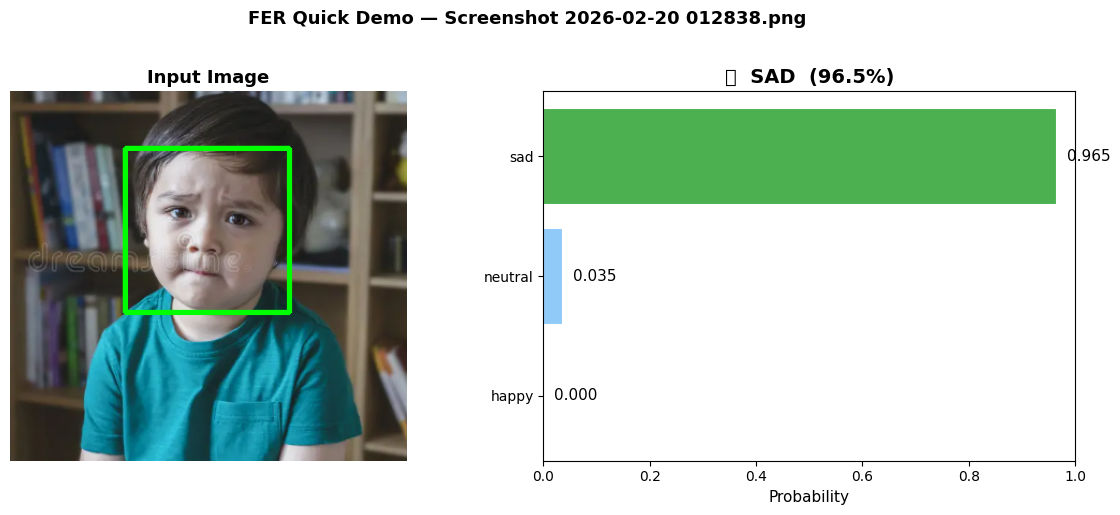


🎯 Predicted Emotion : SAD
   Confidence       : 0.9647 (96.5%)
   Probabilities    : happy: 0.0001  |  neutral: 0.0352  |  sad: 0.9647


In [ ]:
# ==========================================
# CELL 21 — Quick Demo (FER)
# Upload an image OR capture from webcam,
# then see the model’s prediction instantly.
# Perfect for a live guide demo!
# ==========================================

from google.colab import files
from IPython.display import display, HTML
from google.colab.output import eval_js
from base64 import b64decode

# ============================================================
# Helper — Run inference on a single image and display results
# ============================================================

def _demo_predict(image_path):
    """
    Run FER inference on image_path and display a rich
    visual output: input image with face box + probability
    bar chart + headline prediction.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ Cannot read image: {image_path}")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Face detection
    faces = _face_detector.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        face_rgb = img_rgb
        box = None
        print("⚠️  No face detected — running on full image.")
    else:
        x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        face_rgb = img_rgb[y:y+h, x:x+w]
        box = (x, y, w, h)
        print("✅ Face detected!")

    # Preprocess & infer
    pil_face = Image.fromarray(face_rgb)
    tensor   = _test_transform(pil_face).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = test_model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx     = int(np.argmax(probs))
    pred_emotion = _EMOTION_LABELS[pred_idx]
    confidence   = float(probs[pred_idx])
    probs_dict   = {label: float(probs[i]) for i, label in enumerate(_EMOTION_LABELS)}

    # ---- Rich Visual Output ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left — Input image with face bounding box
    display_img = img_rgb.copy()
    if box:
        x, y, w, h = box
        cv2.rectangle(display_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    axes[0].imshow(display_img)
    axes[0].set_title("Input Image", fontsize=13, fontweight='bold')
    axes[0].axis("off")

    # Right — Probability bar chart
    bar_colors = []
    for l in _EMOTION_LABELS:
        if l == pred_emotion:
            bar_colors.append("#4CAF50")  # green for predicted
        else:
            bar_colors.append("#90CAF9")  # light blue for others

    bars = axes[1].barh(_EMOTION_LABELS, probs, color=bar_colors, edgecolor='white', linewidth=0.8)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability", fontsize=11)
    axes[1].set_title(f"🎯  {pred_emotion.upper()}  ({confidence:.1%})", fontsize=14, fontweight='bold')
    for i, p in enumerate(probs):
        axes[1].text(p + 0.02, i, f"{p:.3f}", va="center", fontsize=11)

    plt.suptitle(
        f"FER Quick Demo — {os.path.basename(image_path)}",
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()

    # Text summary
    print(f"\n{'='*50}")
    print(f"🎯 Predicted Emotion : {pred_emotion.upper()}")
    print(f"   Confidence       : {confidence:.4f} ({confidence:.1%})")
    print(f"   Probabilities    : ", end="")
    print("  |  ".join([f"{k}: {v:.4f}" for k, v in probs_dict.items()]))
    print(f"{'='*50}")

# ============================================================
# Option A — Upload image from device
# ============================================================

def demo_upload():
    """Upload one or more images from your device and test each."""
    print("📤 Upload one or more images (jpg / png):\n")
    uploaded = files.upload()

    for filename in uploaded.keys():
        save_path = f"/content/{filename}"
        with open(save_path, "wb") as f:
            f.write(uploaded[filename])
        print(f"\n📸 Testing: {filename}")
        _demo_predict(save_path)

# ============================================================
# Option B — Capture from webcam
# ============================================================

def demo_webcam():
    """Capture a photo from your webcam and test it."""

    JS_CODE = """
    async function captureWebcam() {
        const div = document.createElement('div');
        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.borderRadius = '10px';
        video.style.margin = '10px auto';

        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Wait a moment for the camera to adjust
        await new Promise(resolve => setTimeout(resolve, 1500));

        const canvas = document.createElement('canvas');
        canvas.width  = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', 0.9);
    }
    """

    print("📷 Opening webcam... (allow camera access)")
    data_url = eval_js(JS_CODE + '\ncaptureWebcam()')

    # Decode base64 image
    header, encoded = data_url.split(',', 1)
    img_bytes = b64decode(encoded)

    webcam_path = "/content/webcam_capture.jpg"
    with open(webcam_path, "wb") as f:
        f.write(img_bytes)

    print("✅ Photo captured!\n")
    _demo_predict(webcam_path)

# ============================================================
# 🚀 RUN THE DEMO — Interactive Mode Selection
# ============================================================

print("===========================================")
print("🚀 FER Quick Demo — Choose Input Mode")
print("===========================================")
print("  1 → Upload image(s) from your device")
print("  2 → Capture a photo via webcam")
print("===========================================")

choice = input("\nEnter your choice (1 or 2): ").strip()

if choice == "1":
    demo_upload()
elif choice == "2":
    demo_webcam()
else:
    print("❌ Invalid choice. Please enter 1 or 2. Re-run this cell to try again.")